# F1 Tyre Degradation & Race Analysis

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12,6)


In [2]:

df = pd.read_csv('f1_strategy_dataset_v1.csv')
df.head()


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


## Dataset Overview

In [3]:

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24914 entries, 0 to 24913
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Driver                  24914 non-null  object 
 1   LapNumber               24914 non-null  int64  
 2   Compound                24914 non-null  object 
 3   Stint                   24914 non-null  int64  
 4   TyreLife                24914 non-null  float64
 5   Position                24914 non-null  int64  
 6   LapTime (s)             24914 non-null  float64
 7   Race                    24914 non-null  object 
 8   Year                    24914 non-null  int64  
 9   LapTime_Delta           24914 non-null  float64
 10  Cumulative_Degradation  24914 non-null  float64
 11  PitStop                 24914 non-null  int64  
 12  PitNextLap              24914 non-null  int64  
 13  RaceProgress            24914 non-null  float64
 14  Normalized_TyreLife     24914 non-null

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,24914.000000,24914.000000,24914.000000,24914.000000,24914.000000,24914.0,24914.000000,24914.000000,24914.000000,24914.000000,24914.000000,24914.000000,24914.000000
mean,30.515814,2.224613,14.229349,9.775347,91.638029,2023.0,-0.529557,-15.558949,0.027535,0.030826,0.509260,0.541792,0.009994
std,18.252978,1.049206,9.946288,5.403168,13.645377,0.0,6.585324,14.998320,0.163639,0.172850,0.287120,0.282571,0.968879
min,1.000000,1.000000,1.000000,1.000000,67.012000,2023.0,-64.690000,-74.978000,0.000000,0.000000,0.012821,0.017241,-13.000000
25%,15.000000,1.000000,7.000000,5.000000,81.425750,2023.0,-0.291000,-21.062500,0.000000,0.000000,0.260870,0.300000,0.000000
50%,30.000000,2.000000,12.000000,10.000000,90.913000,2023.0,0.000000,-16.393000,0.000000,0.000000,0.509091,0.545455,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.283750,2023.0,0.229000,-5.352250,0.000000,0.000000,0.757576,0.785714,0.000000
max,78.000000,8.000000,58.000000,20.000000,174.634000,2023.0,61.267000,59.209000,1.000000,1.000000,1.000000,1.000000,13.000000


## Lap Time Trend (Top Drivers)

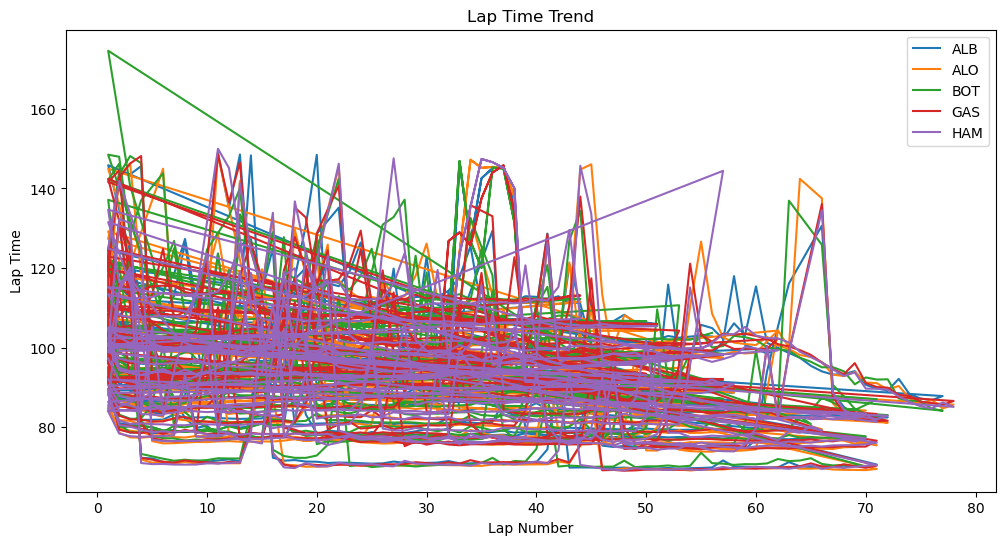

In [4]:

for driver in df['Driver'].unique()[:5]:
    temp = df[df['Driver'] == driver]
    plt.plot(temp['LapNumber'], temp['LapTime (s)'], label=driver)

plt.legend()
plt.xlabel("Lap Number")
plt.ylabel("Lap Time")
plt.title("Lap Time Trend")
plt.show()


## Tyre Degradation vs Lap Time

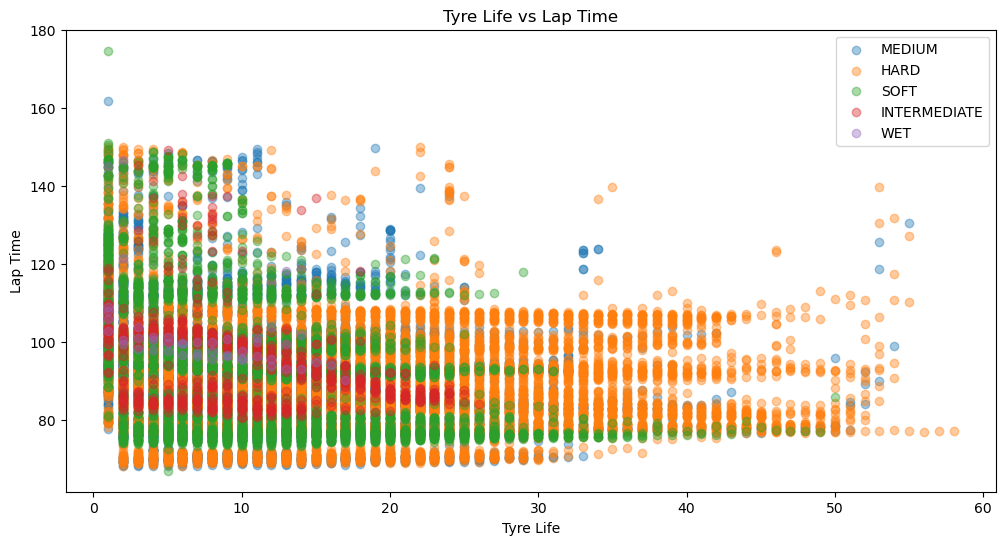

In [5]:

for compound in df['Compound'].unique():
    temp = df[df['Compound'] == compound]
    plt.scatter(temp['TyreLife'], temp['LapTime (s)'], label=compound, alpha=0.4)

plt.legend()
plt.xlabel("Tyre Life")
plt.ylabel("Lap Time")
plt.title("Tyre Life vs Lap Time")
plt.show()


## Average Lap Time per Compound

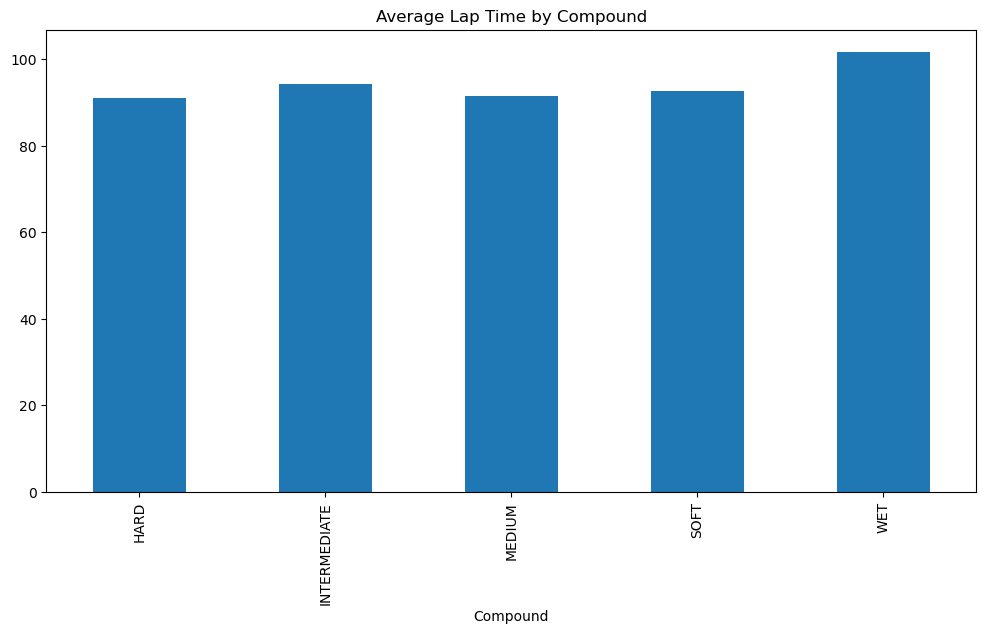

In [6]:

df.groupby('Compound')['LapTime (s)'].mean().plot(kind='bar')
plt.title("Average Lap Time by Compound")
plt.show()


## Position Change Analysis

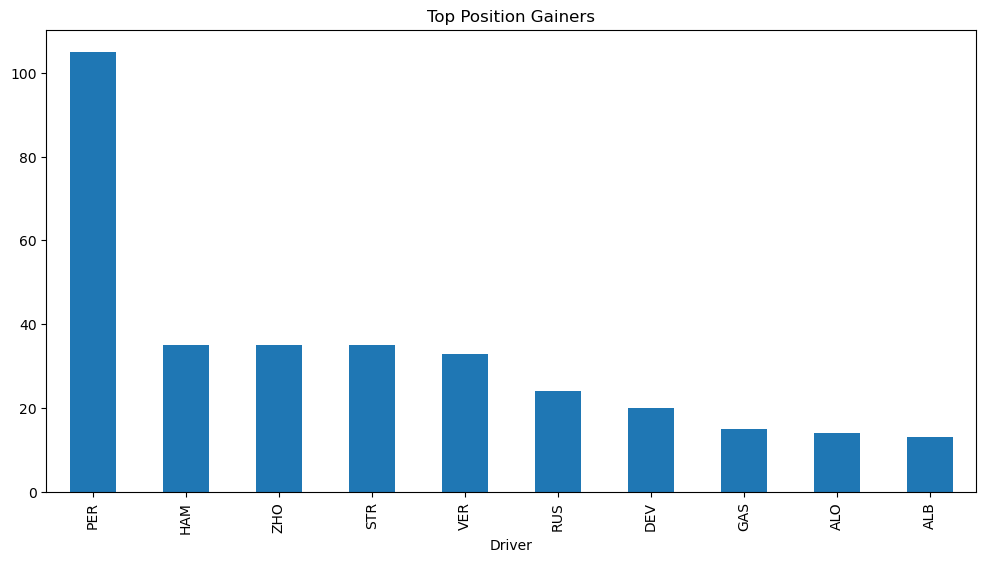

In [7]:

df.groupby('Driver')['Position_Change'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Position Gainers")
plt.show()


## Pit Stop Impact

In [8]:

pit = df[df['PitStop'] == 1]
non_pit = df[df['PitStop'] == 0]

print("Avg Lap Time (Pit):", pit['LapTime (s)'].mean())
print("Avg Lap Time (No Pit):", non_pit['LapTime (s)'].mean())


Avg Lap Time (Pit): 110.74984548104956
Avg Lap Time (No Pit): 91.09689066369491


## Cumulative Degradation

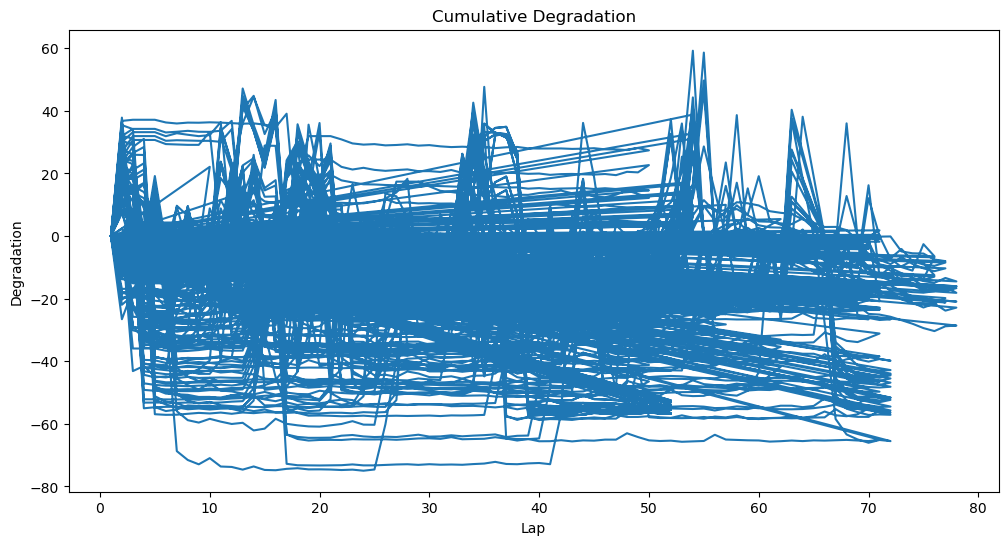

In [9]:

plt.plot(df['LapNumber'], df['Cumulative_Degradation'])
plt.title("Cumulative Degradation")
plt.xlabel("Lap")
plt.ylabel("Degradation")
plt.show()


## Race Progress Impact

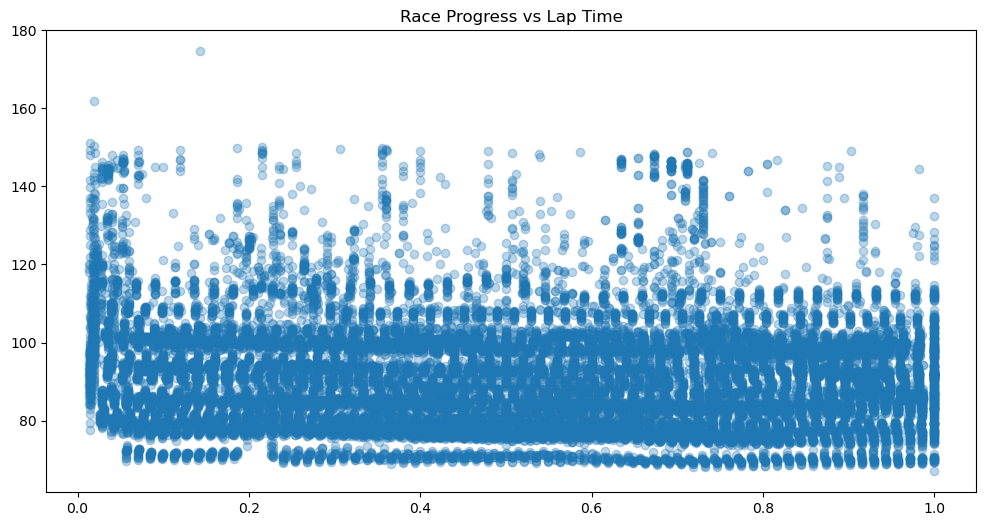

In [10]:

plt.scatter(df['RaceProgress'], df['LapTime (s)'], alpha=0.3)
plt.title("Race Progress vs Lap Time")
plt.show()


## Correlation Heatmap

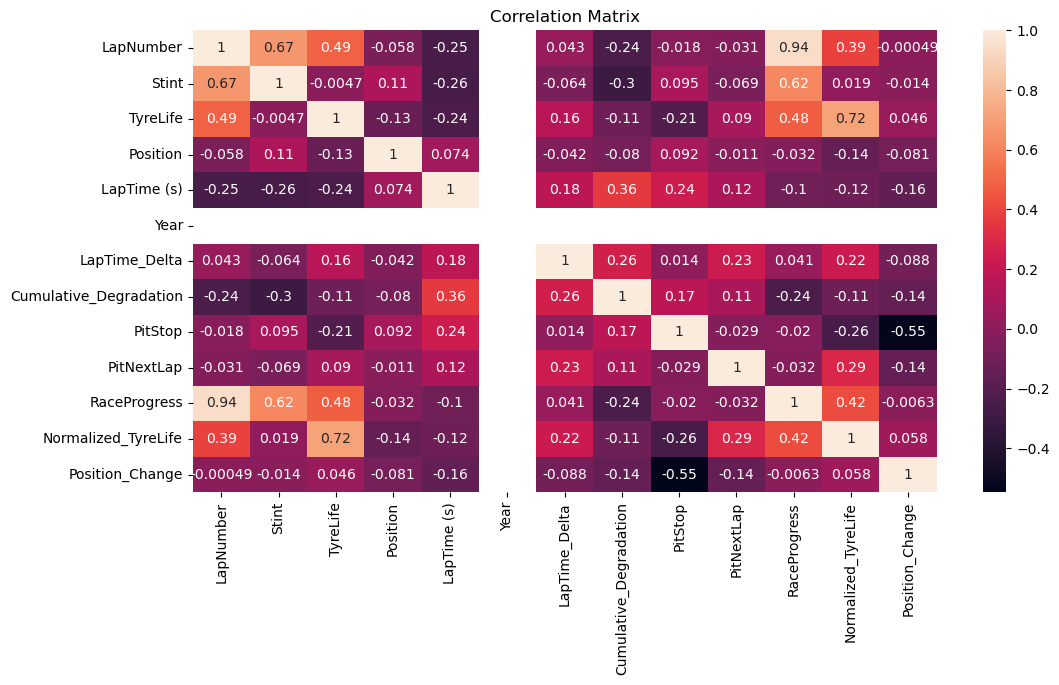

In [11]:

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()
